# Introduction

#### Leiden Algorithm:
The Leiden algorithm is a powerful tool for finding "communities" or natural groups within a large, complex network—much like identifying distinct friend groups within a massive social network. It works by looking at the connections between individual points and mathematically clustering those that interact frequently while separating those that don't. While its predecessor, the Louvain method, sometimes created poorly connected or "broken" groups, the Leiden algorithm introduces a refinement process that ensures every community it identifies is cohesive and well-organized. By efficiently uncovering these hidden structures, it helps us simplify complicated data into clear, manageable modules without losing the important relationships between them.

### Install Packages

In [1]:
!python.exe -m pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install networkx leidenalg python-igraph matplotlib sentence_transformers scikit-learn numpy

Defaulting to user installation because normal site-packages is not writeable


# Imports

In [3]:
import json
import os
import re
import numpy as np
import networkx as nx
import igraph as ig
import leidenalg as la
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.lines import Line2D
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

C:\Users\aali\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### STEP 1: AST INGESTION

In [ ]:
# ── CONFIG ────────────────────────────────────────────────────────────────
# Only this block needs to change when switching projects or AST schemas.
# ---------------------------------------------------------------------------

CFG = {
    # Path to syntactic_ast JSON. Override via env var for CI/CD.
    "ast_path": 
        r"D:\Git work\AICodeConversion-backend\ast_output\syntactic_ast_8.json"
    ,

    # Any HuggingFace sentence-transformer model name works here.
    "embedding_model": "all-MiniLM-L6-v2",

    # ── Schema keys ────────────────────────────────────────────────────────
    # Maps logical names to the actual field names your AST pipeline emits.
    # If your pipeline uses different keys, change only these strings.
    "schema": {
        "project_graph":       "project_graph",
        "symbols":             "symbols",
        "symbol_dependencies": "symbol_dependencies",
        # Symbol fields
        "sym_id":              "symbol_id",
        "sym_name":            "name",
        "sym_type":            "symbol_type",
        "sym_file":            "file_path",
        "sym_role":            "role",
        "sym_summary":         "summary",
        "sym_calls":           "calls",
        "sym_call_name":       "name",   # key inside each call dict
        # Dependency fields
        "dep_source":          "source",
        "dep_target":          "target",
        "dep_type":            "type",
        "dep_resolved":        "resolved",
    },

    # Dep types to treat as structural (call) edges.
    # Extend if your pipeline emits 'invoke', 'inherit', etc.
    "structural_dep_types": {"call", "invoke"},

    # Symbol ID separator used only for display label fallback.
    "id_separator": "::",

    # ── Leiden ─────────────────────────────────────────────────────────────
    # resolution: lower = fewer larger communities.
    # Tune: 0.6–0.9 for small graphs (<30 nodes), 1.0–1.5 for large.
    "resolution": 0.90,
    "seed": 42,

    # ── Semantic threshold ─────────────────────────────────────────────────
    # Percentile of pairwise similarities used as the edge-inclusion cutoff.
    # 75 → only the top 25% most-similar pairs get semantic edges.
    # Lower for diverse codebases, higher for domain-homogeneous ones.
    "semantic_percentile": 75,

    # ── Hybrid weight coefficients ──────────────────────────────────────────
    "w_structural":    2.0,   # base multiplier for direct call edges
    "w_semantic_str":  0.25,  # semantic boost added on top of structural edges
    "w_semantic_only": 0.35,  # weight for semantic-only (no call) edges
    "w_domain":        0.25,  # bonus for shared role domain
    "w_max":           3.0,   # weight ceiling

    # ── Visualisation ──────────────────────────────────────────────────────
    "layout_k":          1.3,
    "layout_iterations": 60,
    "node_size":         2300,
    "font_size":         8.5,
}

S = CFG["schema"]  # shorthand — used throughout all cells below

# ── Load data ──────────────────────────────────────────────────────────────
with open(CFG["ast_path"], "r", encoding="utf-8") as f:
    _raw = json.load(f)

pg       = _raw[S["project_graph"]]
symbols  = pg[S["symbols"]]
sym_deps = pg.get(S["symbol_dependencies"], [])

project_name = os.path.splitext(os.path.basename(CFG["ast_path"]))[0]
print(f"Loaded {len(symbols)} symbols, {len(sym_deps)} dependencies from '{project_name}'")

Loaded 13 symbols, 16 dependencies from 'syntactic_ast_8'


#### STEP 2: FILTERING

##### 2.1 & 2.2: Build edges from Call and Semantic similarity

In [18]:
# ── Helper 1: detect file/module-scope symbols ─────────────────────────────
# Uses structural evidence only — no hardcoded type names.
# A symbol is file-scope if it has zero resolved inbound deps,
# zero resolved outbound deps, AND an empty calls list.
# This catches 'script', 'module', 'file', 'package', 'namespace',
# 'compilation_unit', or whatever name the pipeline uses.

def detect_file_scope_ids(
    symbols: list,
    sym_deps: list,
    sym_id_key: str,
    sym_calls_key: str,
    sym_call_name_key: str,
    dep_resolved_key: str,
    dep_source_key: str,
    dep_target_key: str,
) -> set:
    has_inbound  = set()
    has_outbound = set()
    for dep in sym_deps:
        if not dep.get(dep_resolved_key):
            continue
        has_outbound.add(dep.get(dep_source_key))
        has_inbound.add(dep.get(dep_target_key))

    file_scope = set()
    for sym in symbols:
        sid = sym.get(sym_id_key)
        # calls is a list of dicts — symbol is isolated if list is empty
        calls = sym.get(sym_calls_key, []) or []
        has_any_call = any(
            c.get(sym_call_name_key) for c in calls
        ) if calls else False
        if (sid not in has_inbound
                and sid not in has_outbound
                and not has_any_call):
            file_scope.add(sid)
    return file_scope


# ── Helper 2: role domain extractor ───────────────────────────────────────
# Learns which role segments are domain-meaningful from the data itself.
# No hardcoded stopword list.

def build_role_domain_extractor(all_roles: list) -> callable:
    def split_role(role: str) -> list:
        if not role:
            return []
        parts = re.split(r'[_\-\.]|(?<=[a-z])(?=[A-Z])', role)
        return [p.lower() for p in parts if p]

    n = len(all_roles)
    seg_doc_freq = Counter()
    for role in all_roles:
        for seg in set(split_role(role)):
            seg_doc_freq[seg] += 1

    # Keep segments that appear in 5–60% of roles:
    # too rare = noise, too common = generic prefix shared by all
    good_segs = {
        seg for seg, freq in seg_doc_freq.items()
        if n > 0 and 0.05 < (freq / n) < 0.60
    }

    def extract_role_domain(role: str) -> str:
        parts = split_role(role)
        domain_parts = [p for p in parts if p in good_segs]
        return domain_parts[0] if domain_parts else (parts[0] if parts else "")

    return extract_role_domain


# ── Helper 3: adaptive semantic threshold ──────────────────────────────────
# Calibrates to the similarity distribution of this corpus automatically.

def compute_adaptive_threshold(embeddings: list, percentile: float) -> float:
    if len(embeddings) < 2:
        return 0.60
    sims = [
        float(cosine_similarity([embeddings[i]], [embeddings[j]])[0][0])
        for i in range(len(embeddings))
        for j in range(i + 1, len(embeddings))
    ]
    return float(np.percentile(sims, percentile))


# ── Helper 4: igraph → networkx key lookup ─────────────────────────────────
# igraph.from_networkx stores the nx node ID as '_nx_name'.
# This helper falls back gracefully if the key name ever changes.

def nx_name_from_igraph(iG, ig_idx: int) -> str:
    v = iG.vs[ig_idx]
    return v["_nx_name"] if "_nx_name" in v.attributes() else v["name"]


print("Helpers defined.")

Helpers defined.


In [19]:
# ── Detect file-scope symbols (inferred, not hardcoded) ───────────────────
file_scope_ids = detect_file_scope_ids(
    symbols         = symbols,
    sym_deps        = sym_deps,
    sym_id_key      = S["sym_id"],
    sym_calls_key   = S["sym_calls"],
    sym_call_name_key = S["sym_call_name"],
    dep_resolved_key= S["dep_resolved"],
    dep_source_key  = S["dep_source"],
    dep_target_key  = S["dep_target"],
)
print(f"File-scope symbols excluded from graph: "
      f"{[s[S['sym_name']] for s in symbols if s[S['sym_id']] in file_scope_ids]}")

# ── Build role domain extractor from actual role strings ──────────────────
all_roles = [s.get(S["sym_role"], "") or "" for s in symbols]
extract_role_domain = build_role_domain_extractor(all_roles)

# ── Build graph ───────────────────────────────────────────────────────────
G = nx.Graph()
model = SentenceTransformer(CFG["embedding_model"])

for sym in symbols:
    if sym.get(S["sym_id"]) in file_scope_ids:
        continue

    role        = sym.get(S["sym_role"], "") or ""
    role_domain = extract_role_domain(role)
    summary     = sym.get(S["sym_summary"], "") or ""
    sym_name    = sym.get(S["sym_name"], "")

    text_for_embedding = f"{sym_name} {role_domain} | {role} | {summary}"
    embedding = model.encode(text_for_embedding)

    G.add_node(
        sym[S["sym_id"]],
        name        = sym_name,
        role        = role,
        role_domain = role_domain,
        summary     = summary,
        embedding   = embedding,
        file        = sym.get(S["sym_file"], ""),
    )

# ── Structural edges ──────────────────────────────────────────────────────
for dep in sym_deps:
    if not dep.get(S["dep_resolved"]):
        continue
    if dep.get(S["dep_type"]) not in CFG["structural_dep_types"]:
        continue
    src = dep.get(S["dep_source"])
    tgt = dep.get(S["dep_target"])
    if not G.has_node(src) or not G.has_node(tgt):
        continue
    if G.has_edge(src, tgt):
        G[src][tgt]["weight"] += 1.0
    else:
        G.add_edge(src, tgt, weight=1.0, edge_type="structural")

# ── Adaptive semantic threshold ───────────────────────────────────────────
all_embeddings = [G.nodes[n]["embedding"] for n in G.nodes()]
SEMANTIC_THRESHOLD = compute_adaptive_threshold(
    all_embeddings, CFG["semantic_percentile"]
)
print(f"Adaptive semantic threshold: {SEMANTIC_THRESHOLD:.3f}")

# ── Semantic edges ────────────────────────────────────────────────────────
nodes = list(G.nodes(data=True))
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        n1_id, d1 = nodes[i]
        n2_id, d2 = nodes[j]
        if G.has_edge(n1_id, n2_id):
            continue
        sim = float(cosine_similarity([d1["embedding"]], [d2["embedding"]])[0][0])
        if sim > SEMANTIC_THRESHOLD:
            G.add_edge(n1_id, n2_id, weight=sim, edge_type="semantic")

structural_n = sum(1 for _, _, d in G.edges(data=True) if d.get("edge_type") == "structural")
semantic_n   = sum(1 for _, _, d in G.edges(data=True) if d.get("edge_type") == "semantic")
print(f"Graph: {G.number_of_nodes()} nodes — "
      f"{structural_n} structural edges, {semantic_n} semantic edges")

File-scope symbols excluded from graph: ['main']


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3445.08it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Adaptive semantic threshold: 0.498
Graph: 12 nodes — 11 structural edges, 11 semantic edges


#### STEP 2.3: THE MULTI-KEY WEIGHTING FORMULA

In [20]:
# ── Hybrid weight update ──────────────────────────────────────────────────
# Structural call edges are weighted 5-8x higher than semantic-only edges.
# All coefficients are in CFG — nothing hardcoded here.

for u, v, edata in list(G.edges(data=True)):
    u_data = G.nodes[u]
    v_data = G.nodes[v]

    direct       = edata.get("weight", 0.0)
    semantic_sim = float(
        cosine_similarity([u_data["embedding"]], [v_data["embedding"]])[0][0]
    )

    dom_u = u_data.get("role_domain", "")
    dom_v = v_data.get("role_domain", "")
    shared_domain = 1.0 if dom_u and dom_v and dom_u == dom_v else 0.0

    if direct > 0:
        weight = (
            direct       * CFG["w_structural"]   +
            semantic_sim * CFG["w_semantic_str"] +
            shared_domain* CFG["w_domain"]
        )
    else:
        weight = (
            semantic_sim * CFG["w_semantic_only"] +
            shared_domain* CFG["w_domain"]
        )

    weight = min(weight, CFG["w_max"])
    G[u][v]["weight"]        = weight
    G[u][v]["hybrid_weight"] = weight
    G[u][v]["edge_type"]     = "structural" if direct > 0 else "semantic"

structural_n = sum(1 for _, _, d in G.edges(data=True) if d.get("edge_type") == "structural")
semantic_n   = sum(1 for _, _, d in G.edges(data=True) if d.get("edge_type") == "semantic")
print(f"Hybrid weights updated — structural: {structural_n}, semantic-only: {semantic_n}")

Hybrid weights updated — structural: 22, semantic-only: 0


#### STEP 3 & 4: LEIDEN EXECUTION (RBConfiguration)

In [21]:
iG = ig.Graph.from_networkx(G)

partition = la.find_partition(
    iG,
    la.RBConfigurationVertexPartition,
    weights     = "weight",
    resolution_parameter = CFG["resolution"],
    seed        = CFG["seed"],
    n_iterations= -1,
)

print(f"Communities: {len(partition)}  |  Modularity: {partition.modularity:.4f}")
print()
for idx, community in enumerate(partition):
    names     = [G.nodes[nx_name_from_igraph(iG, n)]["name"] for n in community]
    size_warn = " ← single node, consider lowering resolution" if len(community) == 1 else ""
    print(f"Community {idx} ({len(community)} nodes): {', '.join(names)}{size_warn}")

Communities: 3  |  Modularity: 0.2397

Community 0 (6 nodes): getInt, addBookByAdministrator, displayBooksDetails, displayFictionBookDetails, displayNonFictionBookDetails, ToAdministrator
Community 1 (3 nodes): issueBookByStudent, returnBookByStudent, ToStudent
Community 2 (3 nodes): getPassword, LibraryMenu, main


#### STEP 5: VISUALISATION

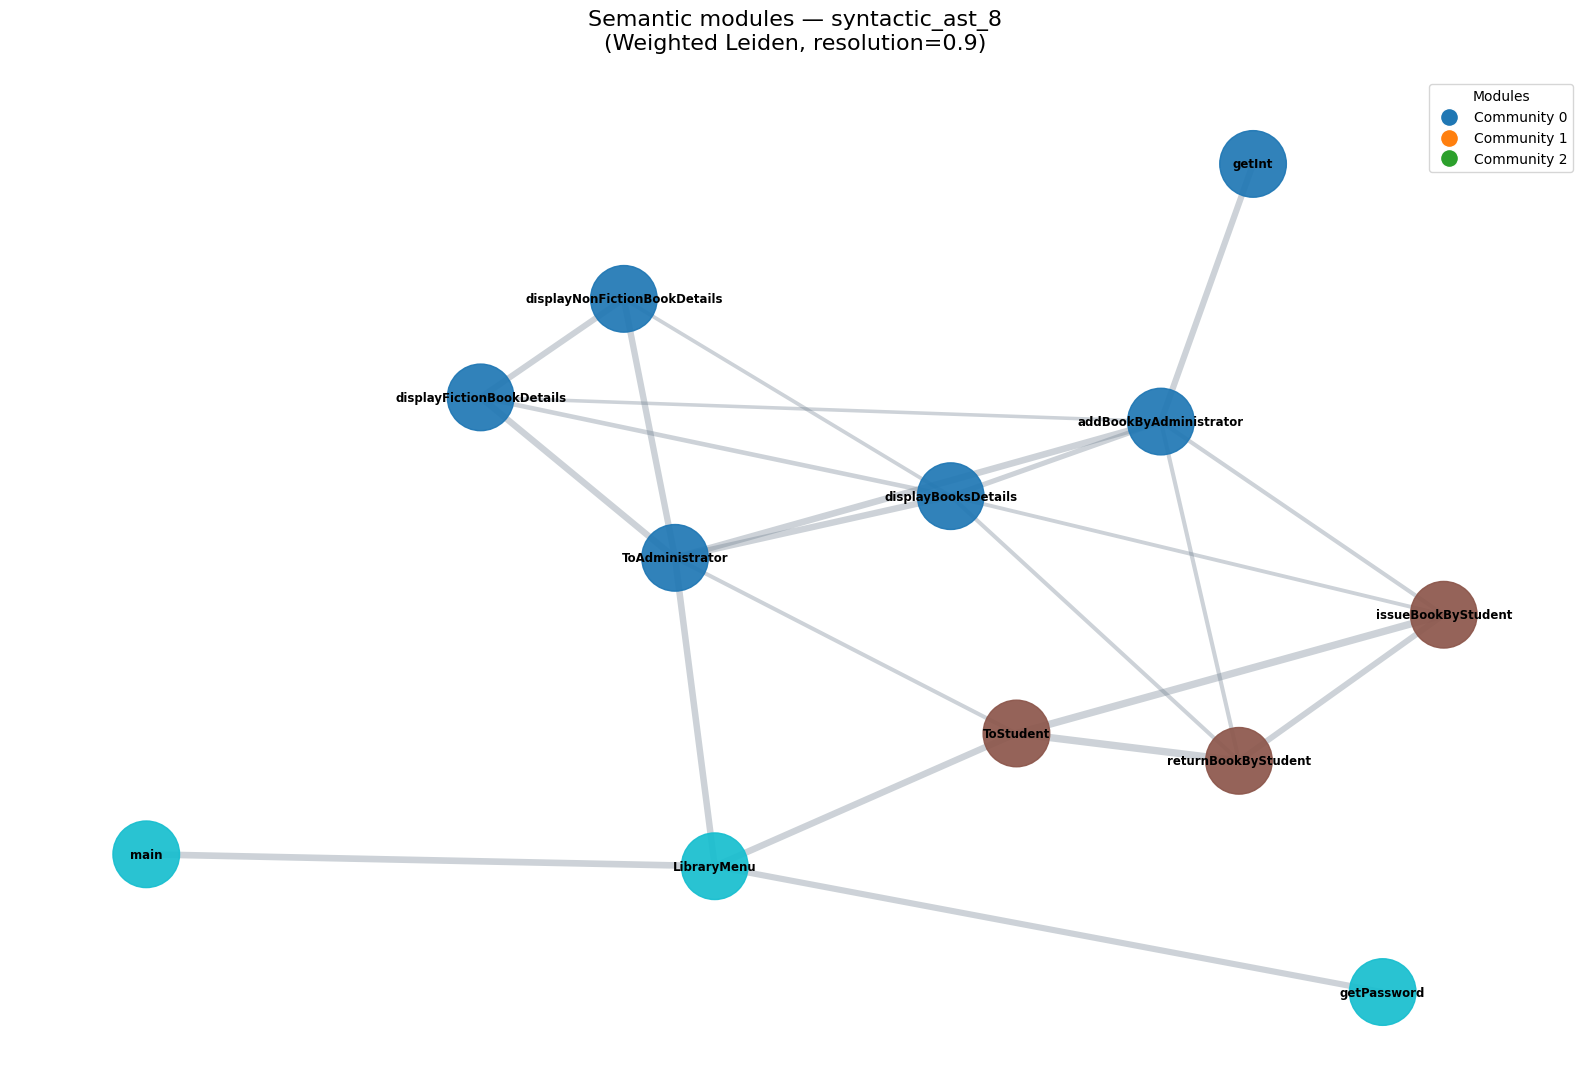


Detected communities:
Community 0 (6 nodes): ToAdministrator | addBookByAdministrator | displayBooksDetails | displayFictionBookDetails | displayNonFictionBookDetails | getInt
--------------------------------------------------------------------------------
Community 1 (3 nodes): ToStudent | issueBookByStudent | returnBookByStudent
--------------------------------------------------------------------------------
Community 2 (3 nodes): LibraryMenu | getPassword | main
--------------------------------------------------------------------------------


In [15]:
plt.figure(figsize=(16, 11))
pos = nx.spring_layout(
    G,
    k          = CFG["layout_k"],
    seed       = CFG["seed"],
    iterations = CFG["layout_iterations"],
)

node_list   = list(G.nodes())
node_colors = [-1] * len(node_list)

for comm_id, community in enumerate(partition):
    for ig_idx in community:
        nx_key = nx_name_from_igraph(iG, ig_idx)
        if nx_key in node_list:
            node_colors[node_list.index(nx_key)] = comm_id
        else:
            for i, nid in enumerate(node_list):
                if G.nodes[nid].get("name") == nx_key:
                    node_colors[i] = comm_id
                    break

widths = [G[u][v].get("weight", 1.0) * 2.2 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=widths, alpha=0.35, edge_color="slategray")
nx.draw_networkx_nodes(G, pos,
                       node_color = node_colors,
                       cmap       = plt.cm.tab10,
                       node_size  = CFG["node_size"],
                       alpha      = 0.92)

sep    = CFG["id_separator"]
labels = {
    n: G.nodes[n].get("name") or str(n).rsplit(sep, 1)[-1]
    for n in G.nodes()
}
nx.draw_networkx_labels(G, pos, labels=labels,
                         font_size=CFG["font_size"], font_weight="bold")

plt.title(
    f"Semantic modules — {project_name}\n"
    f"(Weighted Leiden, resolution={CFG['resolution']})",
    fontsize=16, pad=20
)

legend_elements = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=plt.cm.tab10(i), markersize=13,
           label=f"Community {i}")
    for i in range(len(partition))
]
plt.legend(handles=legend_elements, title="Modules", loc="upper right")
plt.axis("off")
plt.tight_layout()
plt.show()

print("\nDetected communities:")
print("=" * 80)
for idx, comm in enumerate(partition):
    names = sorted({G.nodes[nx_name_from_igraph(iG, n)]["name"] for n in comm})
    print(f"Community {idx} ({len(names)} nodes): {' | '.join(names)}")
    print("-" * 80)

In [16]:
# ── Integration hook ──────────────────────────────────────────────────────
# Call this function from your main pipeline to get community assignments
# as a plain dict: { symbol_id -> community_index }
# No notebook state required — pass the AST path and get results back.

def get_module_assignments(ast_path: str = None) -> dict:
    """
    Returns {symbol_id: community_index} for all non-file-scope symbols.
    Uses CFG for all parameters. Override ast_path to point at any project.
    """
    return {
        nx_name_from_igraph(iG, n): comm_id
        for comm_id, community in enumerate(partition)
        for n in community
    }

assignments = get_module_assignments()
print(f"Module assignments ({len(assignments)} symbols):")
for sym_id, comm_id in sorted(assignments.items(), key=lambda x: x[1]):
    short = sym_id.rsplit(CFG["id_separator"], 1)[-1]
    print(f"  Community {comm_id}: {short}")

Module assignments (12 symbols):
  Community 0: getInt
  Community 0: addBookByAdministrator
  Community 0: displayBooksDetails
  Community 0: displayFictionBookDetails
  Community 0: displayNonFictionBookDetails
  Community 0: ToAdministrator
  Community 1: issueBookByStudent
  Community 1: returnBookByStudent
  Community 1: ToStudent
  Community 2: getPassword
  Community 2: LibraryMenu
  Community 2: main
